In [28]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Dense, Input, GlobalMaxPooling1D, Conv1D, MaxPooling1D, Embedding
from tensorflow.keras.models import Model

In [ ]:
!wget https://lazyprogrammer.me/course_files/spam.csv
# arrega os dados

--2026-08-12 17:04:14--  https://lazyprogrammer.me/course_files/spam.csv
Resolvendo lazyprogrammer.me (lazyprogrammer.me)... 2606:4700:3037::6815:17d2, 2606:4700:3036::ac43:d5a6, 104.21.23.210, ...
Conectando-se a lazyprogrammer.me (lazyprogrammer.me)|2606:4700:3037::6815:17d2|:443... conectado.
A requisição HTTP foi enviada, aguardando resposta... 200 OK
Tamanho: 503663 (492K) [text/csv]
Salvando em: ‘spam.csv.1’

spam.csv.1          100%[===================>] 491,86K  3,02MB/s    em 0,2s    

2026-08-12 17:04:15 (3,02 MB/s) - ‘spam.csv.1’ salvo [503663/503663]



In [ ]:
df = pd.read_csv('/home/beuren/Documentos/LAMIA-Bootcamp/card-17/course/NLP/spam.csv',encoding='ISO-8859-1')
# transforma em um dataframe pandas

In [31]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [ ]:
df =df.drop(['Unnamed: 2','Unnamed: 3','Unnamed: 4'], axis = 1)
# retira as colunas invalidas

In [33]:
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [34]:
df.columns = ['labels','data']

In [35]:
df.head()

,labels,data
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
df['labels'] = df['labels'].map({'ham':0, 'spam':1})
# para cada rotulo de saida troca por 0 ou 1,, 0 para nao span, e 1 para spam
y=df['labels'].values

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(df['data'],y,test_size=0.33)
#separa os dads de treino e test

In [ ]:
MAX_VOCAB_SIZE = 20000
tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE)# coloca um limite no vocabulario
tokenizer.fit_on_texts((x_train))# separa cada palavra da frase
sequences_train = tokenizer.texts_to_sequences(x_train)# faz uma seuqncia de inteiros para se referir a cada palavra
sequences_test = tokenizer.texts_to_sequences(x_test)# mesma coisa
print(sequences_train)

[[2274, 659, 8, 40, 1474, 1773, 277, 6, 16, 177, 5, 1774, 154, 1, 118, 30, 17, 2275, 2276, 156, 241, 81, 258, 2277, 203, 242, 66, 321], [131, 19, 3, 830, 36, 10, 92, 10, 3455], [2, 16, 1276, 435, 3456, 73, 15, 84], [66, 22, 1117, 2278, 40, 1475, 500, 8, 3457, 211, 152, 22, 45, 44, 449, 22, 42, 45, 44, 471, 309, 152, 45, 44, 58, 310, 22, 211, 94, 10, 5, 501, 37, 6, 71, 1775, 3458, 2, 60, 111, 3459], [2, 69, 1, 94, 3, 48, 436, 2, 204, 21, 1476, 5, 66, 502, 2, 68, 3, 3460, 19, 46, 2, 76, 1118], [204, 530, 21, 3, 19, 251, 129, 1000, 14, 2279, 13, 2280, 141, 909, 14, 2279, 342, 15, 13, 180, 2281, 14, 129, 160, 141, 16, 4, 129, 61], [2, 57, 1, 300, 354, 24, 59, 26, 437, 1, 2, 99, 54, 272], [2282, 285, 13, 2283, 100], [60, 1119, 46], [217, 97, 123, 1776, 3461, 8, 2284, 3462, 3, 1120, 2285], [21, 56, 1277, 531, 11, 532, 3463, 18, 1278, 77, 3464], [753, 13, 1121, 343, 754, 12, 2286, 355, 1777, 1778, 450, 660, 1, 118, 17, 2287, 831, 472, 1779, 755], [196, 104, 91, 54, 78, 11, 630, 119, 2, 226, 1

In [ ]:
word2idx = tokenizer.word_index# pega todos os indices tokenizados, ou seja todas as palavras
V=len(word2idx)# quantidade de tokens
print('Found %s unique tokens' % V)

Found 7295 unique tokens


In [ ]:
data_train = pad_sequences(sequences_train)# transforma os indices de cada palavra em um lista de inteiros
# atribui 0 para deixar tudo do mesmo tamanho
print(data_train)
print('Shape of data train tensor', data_train.shape)
T = data_train.shape[1] # quantos tokens tem

[[   0    0    0 ...  242   66  321]
 [   0    0    0 ...   92   10 3455]
 [   0    0    0 ...   73   15   84]
 ...
 [   0    0    0 ...   47 2483 7294]
 [   0    0    0 ...    4   55  115]
 [   0    0    0 ...   13 1392   20]]
Shape of data train tensor (3733, 162)


In [ ]:
data_test = pad_sequences(sequences_test,maxlen=T) # ajusta os o padding do dados de teste para ficar do mesmo tamanho do treino
print('Shape of data test tensor', data_test.shape)


Shape of data test tensor (1839, 162)


In [51]:
T

162

In [ ]:
D= 20 # quantidade de dimensoes escolhida

i = Input(shape=(T,))# define a quantidade de neuronios de entrada, como T tem a dimensao da maior palavra ela sera a entrada, todas sao do mesmo damanho pois o pad_seuqnces preencheu com 0
x = Embedding(V+1,D)(i)# transforma cada frase em umm vetor denso, para que cada palavra seja representada por pesos aprendidos
x=Conv1D(32,3,activation='relu')(x)# features map
x=MaxPooling1D(3)(x)# diminui o array
x=Conv1D(64,3,activation='relu')(x)
x=MaxPooling1D(3)(x)
x=Conv1D(128,3,activation='relu')(x)
x=GlobalMaxPooling1D()(x)
x=Dense(1,activation='sigmoid')(x)# sigmoid pois é uma saida binaria

model = Model(i,x)

In [ ]:
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)
# parametros para o treino

In [48]:
r=model.fit(data_train,y_train,epochs=5,validation_data=(data_test,y_test))

Epoch 1/5
117/117 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.8607 - loss: 0.3829 - val_accuracy: 0.8760 - val_loss: 0.2482
Epoch 2/5
117/117 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.9622 - loss: 0.1148 - val_accuracy: 0.9842 - val_loss: 0.0621
Epoch 3/5
117/117 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.9938 - loss: 0.0223 - val_accuracy: 0.9853 - val_loss: 0.0572
Epoch 4/5
117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.9989 - loss: 0.0058 - val_accuracy: 0.9864 - val_loss: 0.0506
Epoch 5/5
117/117 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9995 - loss: 0.0021 - val_accuracy: 0.9859 - val_loss: 0.0523


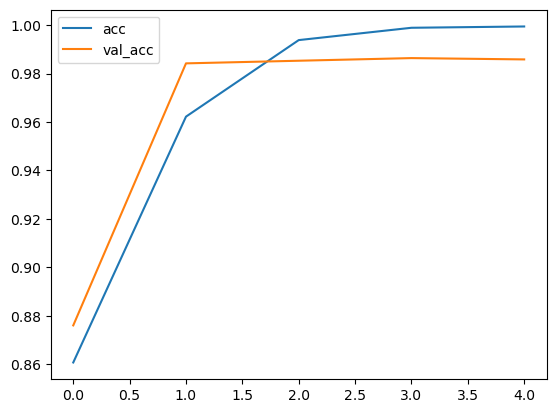

In [ ]:
import matplotlib.pyplot as plt
plt.plot(r.history['accuracy'],label='acc')
plt.plot(r.history['val_accuracy'],label='val_acc')
plt.legend()
# acuracia muito boa, isso pode evidenciar que o dataset é um pouco simples